# Official Statistics Data Quality Audit of Local Authority Indicators in England

This notebook audits local-authority public datasets for missingness, duplicate records, coding consistency, outliers, and reproducible reporting quality.

In [3]:
!pip install duckdb openpyxl --quiet

import pandas as pd
import numpy as np
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from pathlib import Path
import os

print("Current notebook location:")
print(Path.cwd())

base = Path("official_statistics_quality_audit")

folders = [
    base / "data" / "raw",
    base / "data" / "processed",
    base / "outputs" / "tables",
    base / "outputs" / "figures",
    base / "outputs" / "reports",
    base / "sql"
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("\nProject folders created successfully.")
print("Main project folder:")
print(base.resolve())

print("\nRaw data folder:")
print((base / "data" / "raw").resolve())

Current notebook location:
C:\Users\swapn

Project folders created successfully.
Main project folder:
C:\Users\swapn\official_statistics_quality_audit

Raw data folder:
C:\Users\swapn\official_statistics_quality_audit\data\raw


In [10]:
raw_folder = base / "data" / "raw"

csv_files = list(raw_folder.glob("*.csv"))
xlsx_files = list(raw_folder.glob("*.xlsx"))

print("Raw folder location:")
print(raw_folder.resolve())

print("\nCSV files found:", len(csv_files))
for file in csv_files:
    print("-", file.name)

print("\nExcel files found:", len(xlsx_files))
for file in xlsx_files:
    print("-", file.name)

if len(csv_files) == 0 and len(xlsx_files) == 0:
    print("\nNo data files found yet. Put one CSV or Excel file into the raw folder.")

Raw folder location:
C:\Users\swapn\official_statistics_quality_audit\data\raw

CSV files found: 0

Excel files found: 0

No data files found yet. Put one CSV or Excel file into the raw folder.


In [12]:
import requests
from pathlib import Path

base = Path("official_statistics_quality_audit")
raw_folder = base / "data" / "raw"
raw_folder.mkdir(parents=True, exist_ok=True)

url = "https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/housing/datasets/ratioofhousepricetoresidencebasedearningslowerquartileandmedian/current/aff2ratioofhousepricetoresidencebasedearnings.xlsx"

output_file = raw_folder / "ons_house_price_to_earnings_ratio.xlsx"

response = requests.get(url, timeout=60)

print("Status code:", response.status_code)

if response.status_code == 200:
    with open(output_file, "wb") as f:
        f.write(response.content)
    print("Downloaded successfully:")
    print(output_file.resolve())
else:
    print("Download failed.")

Status code: 200
Downloaded successfully:
C:\Users\swapn\official_statistics_quality_audit\data\raw\ons_house_price_to_earnings_ratio.xlsx


In [14]:
import pandas as pd
from pathlib import Path

base = Path("official_statistics_quality_audit")
raw_folder = base / "data" / "raw"

excel_files = list(raw_folder.glob("*.xlsx"))

print("Excel files found:", len(excel_files))
for f in excel_files:
    print("-", f.name)

file_path = excel_files[0]
print("\nReading workbook:")
print(file_path)

xls = pd.ExcelFile(file_path)

print("\nSheets in workbook:")
for i, sheet in enumerate(xls.sheet_names):
    print(i, "-", sheet)

Excel files found: 1
- ons_house_price_to_earnings_ratio.xlsx

Reading workbook:
official_statistics_quality_audit\data\raw\ons_house_price_to_earnings_ratio.xlsx

Sheets in workbook:
0 - Contents
1 - Metadata
2 - Terms and Conditions
3 - 1a
4 - 1b
5 - 1c
6 - 2a
7 - 2b
8 - 2c
9 - 3a
10 - 3b
11 - 3c
12 - 4a
13 - 4b
14 - 4c
15 - 5a
16 - 5b
17 - 5c
18 - 6a
19 - 6b
20 - 6c


In [16]:
# Preview each likely data sheet to find where the actual table starts

for sheet in xls.sheet_names[3:]:  # skip Contents, Metadata, Terms
    preview = pd.read_excel(file_path, sheet_name=sheet, header=None, nrows=8)
    
    print("\n" + "="*80)
    print("SHEET:", sheet)
    print("Shape preview:", preview.shape)
    print(preview.head(8).to_string(index=False, header=False))


SHEET: 1a
Shape preview: (8, 26)
Table 1a - Median house price by country and region, England and Wales, year ending September 2002 to 2025 (£)                      NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN                  NaN
                                                                                                          Code                     Name Year ending Sep 2002 Year ending Sep 2003 Year ending Sep 2004 Year ending Sep 2005 Year ending Sep 2006 Year ending Sep 2007 Year ending Sep 2008 Year ending Sep 2009 Year ending Sep 2010 Y

In [18]:
# Load the local authority median affordability ratio sheet

sheet_name = "5c"

df_raw = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=1,
    na_values=["[x]", "[z]", ":", "..", ""]
)

print("Loaded sheet:", sheet_name)
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

df_raw.head()

Loaded sheet: 5c
Rows: 318
Columns: 29


,Country/Region code,Country/Region name,Local authority code,Local authority name,2002,2003,2004,2005,2006,2007,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,5-Year Average
0,E12000001,North East,E06000001,Hartlepool,2.86,3.02,2.82,2.86,4.14,4.63,...,4.82,4.60,4.90,4.54,5.05,4.45,4.80,4.78,4.86,4.79
1,E12000001,North East,E06000002,Middlesbrough,2.83,2.65,3.74,4.23,5.17,5.40,...,5.18,5.23,5.18,5.07,5.33,5.10,5.16,4.73,4.36,4.94
2,E12000001,North East,E06000003,Redcar and Cleveland,2.83,3.95,4.37,4.67,5.66,5.52,...,5.12,5.36,5.03,5.06,5.84,5.12,5.24,5.39,4.70,5.26
3,E12000001,North East,E06000004,Stockton-on-Tees,3.33,4.03,4.54,4.99,5.53,5.64,...,5.37,5.43,4.99,5.19,5.67,5.29,5.35,5.10,4.66,5.21
4,E12000001,North East,E06000005,Darlington,3.42,4.06,5.12,5.96,5.94,5.45,...,4.96,5.26,5.07,5.55,5.32,5.49,5.42,4.94,4.92,5.22


In [20]:
# Clean column names for analysis and SQL

df = df_raw.copy()

def clean_column_name(col):
    col = str(col).strip().lower()
    col = col.replace("/", "_")
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    col = col.replace(".", "")
    col = col.replace("__", "_")
    return col

df.columns = [clean_column_name(col) for col in df.columns]

print("Cleaned columns:")
for col in df.columns:
    print("-", col)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Cleaned columns:
- country_region_code
- country_region_name
- local_authority_code
- local_authority_name
- 2002
- 2003
- 2004
- 2005
- 2006
- 2007
- 2008
- 2009
- 2010
- 2011
- 2012
- 2013
- 2014
- 2015
- 2016
- 2017
- 2018
- 2019
- 2020
- 2021
- 2022
- 2023
- 2024
- 2025
- 5_year_average

Rows: 318
Columns: 29


,country_region_code,country_region_name,local_authority_code,local_authority_name,2002,2003,2004,2005,2006,2007,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,5_year_average
0,E12000001,North East,E06000001,Hartlepool,2.86,3.02,2.82,2.86,4.14,4.63,...,4.82,4.60,4.90,4.54,5.05,4.45,4.80,4.78,4.86,4.79
1,E12000001,North East,E06000002,Middlesbrough,2.83,2.65,3.74,4.23,5.17,5.40,...,5.18,5.23,5.18,5.07,5.33,5.10,5.16,4.73,4.36,4.94
2,E12000001,North East,E06000003,Redcar and Cleveland,2.83,3.95,4.37,4.67,5.66,5.52,...,5.12,5.36,5.03,5.06,5.84,5.12,5.24,5.39,4.70,5.26
3,E12000001,North East,E06000004,Stockton-on-Tees,3.33,4.03,4.54,4.99,5.53,5.64,...,5.37,5.43,4.99,5.19,5.67,5.29,5.35,5.10,4.66,5.21
4,E12000001,North East,E06000005,Darlington,3.42,4.06,5.12,5.96,5.94,5.45,...,4.96,5.26,5.07,5.55,5.32,5.49,5.42,4.94,4.92,5.22


In [22]:
# Basic data quality audit

audit_summary = {
    "total_rows": df.shape[0],
    "total_columns": df.shape[1],
    "duplicate_full_rows": df.duplicated().sum(),
    "unique_local_authority_codes": df["local_authority_code"].nunique(),
    "unique_local_authority_names": df["local_authority_name"].nunique(),
    "missing_local_authority_codes": df["local_authority_code"].isna().sum(),
    "missing_local_authority_names": df["local_authority_name"].isna().sum()
}

print("BASIC AUDIT SUMMARY")
print("=" * 50)

for key, value in audit_summary.items():
    print(f"{key}: {value}")

print("\nMISSING VALUES BY COLUMN")
print("=" * 50)

missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique(dropna=True).values
})

missing_summary

BASIC AUDIT SUMMARY
total_rows: 318
total_columns: 29
duplicate_full_rows: 0
unique_local_authority_codes: 318
unique_local_authority_names: 318
missing_local_authority_codes: 0
missing_local_authority_names: 0

MISSING VALUES BY COLUMN


,column,missing_count,missing_percent,unique_values
0,country_region_code,0,0.00,10
1,country_region_name,0,0.00,10
2,local_authority_code,0,0.00,318
3,local_authority_name,0,0.00,318
4,2002,22,6.92,231
5,2003,2,0.63,257
6,2004,2,0.63,248
7,2005,2,0.63,234
8,2006,2,0.63,240
9,2007,2,0.63,238


In [24]:
# Identify local authorities with any missing affordability values

year_cols = [col for col in df.columns if col.isdigit()]

missing_by_area = df[
    ["country_region_name", "local_authority_code", "local_authority_name"] + year_cols
].copy()

missing_by_area["missing_year_count"] = missing_by_area[year_cols].isna().sum(axis=1)

areas_with_missing = missing_by_area[missing_by_area["missing_year_count"] > 0].copy()

print("Total local authorities with at least one missing year:", areas_with_missing.shape[0])

areas_with_missing = areas_with_missing.sort_values(
    by="missing_year_count",
    ascending=False
)

areas_with_missing[
    ["country_region_name", "local_authority_code", "local_authority_name", "missing_year_count"]
].head(30)

Total local authorities with at least one missing year: 23


,country_region_name,local_authority_code,local_authority_name,missing_year_count
277,South West,E06000053,Isles of Scilly,22
172,London,E09000001,City of London,18
5,North East,E06000047,County Durham,1
167,East of England,E07000241,Welwyn Hatfield,1
280,South West,E06000059,Dorset,1
279,South West,E06000058,"Bournemouth, Christchurch and Poole",1
276,South West,E06000052,Cornwall,1
171,East of England,E07000245,West Suffolk,1
170,East of England,E07000244,East Suffolk,1
169,East of England,E07000243,Stevenage,1


In [26]:
# Show exact missing years for each local authority

def get_missing_years(row):
    missing_years = [year for year in year_cols if pd.isna(row[year])]
    return ", ".join(missing_years)

areas_with_missing_detail = df[
    ["country_region_name", "local_authority_code", "local_authority_name"] + year_cols
].copy()

areas_with_missing_detail["missing_year_count"] = areas_with_missing_detail[year_cols].isna().sum(axis=1)
areas_with_missing_detail["missing_years"] = areas_with_missing_detail.apply(get_missing_years, axis=1)

areas_with_missing_detail = areas_with_missing_detail[
    areas_with_missing_detail["missing_year_count"] > 0
].sort_values("missing_year_count", ascending=False)

# Save output
output_path = base / "outputs" / "tables" / "areas_with_missing_years.csv"
areas_with_missing_detail.to_csv(output_path, index=False)

print("Saved missing-years table to:")
print(output_path.resolve())

areas_with_missing_detail[
    ["country_region_name", "local_authority_code", "local_authority_name", "missing_year_count", "missing_years"]
].head(30)

Saved missing-years table to:
C:\Users\swapn\official_statistics_quality_audit\outputs\tables\areas_with_missing_years.csv


,country_region_name,local_authority_code,local_authority_name,missing_year_count,missing_years
277,South West,E06000053,Isles of Scilly,22,"2002, 2003, 2004, 2005, 2006, 2007, 2008, 2010..."
172,London,E09000001,City of London,18,"2003, 2004, 2005, 2006, 2007, 2008, 2010, 2012..."
5,North East,E06000047,County Durham,1,2002
167,East of England,E07000241,Welwyn Hatfield,1,2002
280,South West,E06000059,Dorset,1,2002
279,South West,E06000058,"Bournemouth, Christchurch and Poole",1,2002
276,South West,E06000052,Cornwall,1,2002
171,East of England,E07000245,West Suffolk,1,2002
170,East of England,E07000244,East Suffolk,1,2002
169,East of England,E07000243,Stevenage,1,2002


In [28]:
# Area-code validation

code_check = df[[
    "country_region_code",
    "country_region_name",
    "local_authority_code",
    "local_authority_name"
]].copy()

# Convert codes to string and strip spaces
code_check["country_region_code"] = code_check["country_region_code"].astype(str).str.strip()
code_check["local_authority_code"] = code_check["local_authority_code"].astype(str).str.strip()

# Standard English/Welsh geography codes usually begin with E or W followed by 8 digits
code_check["valid_country_region_code_pattern"] = code_check["country_region_code"].str.match(r"^[EW][0-9]{8}$")
code_check["valid_local_authority_code_pattern"] = code_check["local_authority_code"].str.match(r"^[EW][0-9]{8}$")

invalid_country_region_codes = code_check[~code_check["valid_country_region_code_pattern"]]
invalid_local_authority_codes = code_check[~code_check["valid_local_authority_code_pattern"]]

duplicate_local_authority_codes = code_check[
    code_check.duplicated(subset=["local_authority_code"], keep=False)
].sort_values("local_authority_code")

print("AREA-CODE VALIDATION SUMMARY")
print("=" * 50)
print("Total records:", code_check.shape[0])
print("Invalid country/region code patterns:", invalid_country_region_codes.shape[0])
print("Invalid local authority code patterns:", invalid_local_authority_codes.shape[0])
print("Duplicate local authority codes:", duplicate_local_authority_codes.shape[0])

print("\nInvalid local authority codes:")
display(invalid_local_authority_codes)

print("\nDuplicate local authority codes:")
display(duplicate_local_authority_codes.head(20))

AREA-CODE VALIDATION SUMMARY
Total records: 318
Invalid country/region code patterns: 0
Invalid local authority code patterns: 0
Duplicate local authority codes: 0

Invalid local authority codes:


,country_region_code,country_region_name,local_authority_code,local_authority_name,valid_country_region_code_pattern,valid_local_authority_code_pattern



Duplicate local authority codes:


,country_region_code,country_region_name,local_authority_code,local_authority_name,valid_country_region_code_pattern,valid_local_authority_code_pattern


In [30]:
# Convert wide dataset into long format: one row per local authority per year

id_cols = [
    "country_region_code",
    "country_region_name",
    "local_authority_code",
    "local_authority_name"
]

year_cols = [col for col in df.columns if col.isdigit()]

df_long = df.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="year",
    value_name="house_price_to_earnings_ratio"
)

df_long["year"] = df_long["year"].astype(int)
df_long["house_price_to_earnings_ratio"] = pd.to_numeric(
    df_long["house_price_to_earnings_ratio"],
    errors="coerce"
)

print("LONG DATASET SUMMARY")
print("=" * 50)
print("Rows:", df_long.shape[0])
print("Columns:", df_long.shape[1])
print("Years:", df_long["year"].min(), "to", df_long["year"].max())
print("Unique local authorities:", df_long["local_authority_code"].nunique())
print("Missing ratio values:", df_long["house_price_to_earnings_ratio"].isna().sum())

# Save long-format dataset
long_output_path = base / "data" / "processed" / "housing_affordability_long.csv"
df_long.to_csv(long_output_path, index=False)

print("\nSaved long-format dataset to:")
print(long_output_path.resolve())

df_long.head()

LONG DATASET SUMMARY
Rows: 7632
Columns: 6
Years: 2002 to 2025
Unique local authorities: 318
Missing ratio values: 61

Saved long-format dataset to:
C:\Users\swapn\official_statistics_quality_audit\data\processed\housing_affordability_long.csv


,country_region_code,country_region_name,local_authority_code,local_authority_name,year,house_price_to_earnings_ratio
0,E12000001,North East,E06000001,Hartlepool,2002,2.86
1,E12000001,North East,E06000002,Middlesbrough,2002,2.83
2,E12000001,North East,E06000003,Redcar and Cleveland,2002,2.83
3,E12000001,North East,E06000004,Stockton-on-Tees,2002,3.33
4,E12000001,North East,E06000005,Darlington,2002,3.42


In [32]:
# Outlier audit using IQR rule within each year

outlier_records = []

for year, group in df_long.groupby("year"):
    values = group["house_price_to_earnings_ratio"].dropna()
    
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    temp = group.copy()
    temp["q1"] = q1
    temp["q3"] = q3
    temp["iqr"] = iqr
    temp["lower_bound"] = lower_bound
    temp["upper_bound"] = upper_bound
    temp["is_outlier"] = (
        (temp["house_price_to_earnings_ratio"] < lower_bound) |
        (temp["house_price_to_earnings_ratio"] > upper_bound)
    )
    
    outlier_records.append(temp)

df_outlier_audit = pd.concat(outlier_records, ignore_index=True)

outliers = df_outlier_audit[df_outlier_audit["is_outlier"] == True].copy()

print("OUTLIER AUDIT SUMMARY")
print("=" * 50)
print("Total long-format records:", df_outlier_audit.shape[0])
print("Total outlier records:", outliers.shape[0])
print("Years covered:", df_outlier_audit["year"].min(), "to", df_outlier_audit["year"].max())

outlier_summary_by_year = (
    outliers.groupby("year")
    .size()
    .reset_index(name="outlier_count")
)

print("\nOutliers by year:")
display(outlier_summary_by_year)

# Save outputs
outliers.to_csv(base / "outputs" / "tables" / "outlier_records.csv", index=False)
outlier_summary_by_year.to_csv(base / "outputs" / "tables" / "outlier_summary_by_year.csv", index=False)

print("\nSaved:")
print((base / "outputs" / "tables" / "outlier_records.csv").resolve())
print((base / "outputs" / "tables" / "outlier_summary_by_year.csv").resolve())

outliers[
    ["country_region_name", "local_authority_code", "local_authority_name", "year", "house_price_to_earnings_ratio", "upper_bound"]
].sort_values(["year", "house_price_to_earnings_ratio"], ascending=[True, False]).head(30)

OUTLIER AUDIT SUMMARY
Total long-format records: 7632
Total outlier records: 110
Years covered: 2002 to 2025

Outliers by year:


,year,outlier_count
0,2002,2
1,2003,1
2,2004,1
3,2005,6
4,2006,3
5,2007,3
6,2008,4
7,2009,5
8,2010,5
9,2011,4



Saved:
C:\Users\swapn\official_statistics_quality_audit\outputs\tables\outlier_records.csv
C:\Users\swapn\official_statistics_quality_audit\outputs\tables\outlier_summary_by_year.csv


,country_region_name,local_authority_code,local_authority_name,year,house_price_to_earnings_ratio,upper_bound
204,London,E09000033,Westminster,2002,11.01,10.06750
191,London,E09000020,Kensington and Chelsea,2002,10.68,10.06750
522,London,E09000033,Westminster,2003,11.41,10.92625
656,North West,E07000117,Burnley,2004,1.99,10.68000
1158,London,E09000033,Westminster,2005,11.30,10.68250
1239,South West,E07000043,North Devon,2005,10.88,10.68250
1145,London,E09000020,Kensington and Chelsea,2005,10.86,10.68250
1138,London,E09000013,Hammersmith and Fulham,2005,10.79,10.68250
954,North East,E06000001,Hartlepool,2005,2.86,10.68250
974,North West,E07000117,Burnley,2005,2.24,10.68250


In [34]:
# Identify local authorities that appear as outliers repeatedly

outlier_summary_by_area = (
    outliers
    .groupby(["country_region_name", "local_authority_code", "local_authority_name"])
    .agg(
        outlier_year_count=("year", "nunique"),
        first_outlier_year=("year", "min"),
        last_outlier_year=("year", "max"),
        max_ratio=("house_price_to_earnings_ratio", "max"),
        average_outlier_ratio=("house_price_to_earnings_ratio", "mean")
    )
    .reset_index()
    .sort_values(["outlier_year_count", "max_ratio"], ascending=[False, False])
)

# Save table
output_path = base / "outputs" / "tables" / "outlier_summary_by_area.csv"
outlier_summary_by_area.to_csv(output_path, index=False)

print("Saved outlier summary by area to:")
print(output_path.resolve())

print("\nTop recurring outlier local authorities:")
outlier_summary_by_area.head(20)

Saved outlier summary by area to:
C:\Users\swapn\official_statistics_quality_audit\outputs\tables\outlier_summary_by_area.csv

Top recurring outlier local authorities:


,country_region_name,local_authority_code,local_authority_name,outlier_year_count,first_outlier_year,last_outlier_year,max_ratio,average_outlier_ratio
10,London,E09000033,Westminster,23,2002,2025,24.79,17.565217
7,London,E09000020,Kensington and Chelsea,22,2002,2025,34.77,21.993182
5,London,E09000013,Hammersmith and Fulham,20,2005,2025,20.04,15.772500
2,London,E09000007,Camden,18,2008,2025,19.65,16.419444
4,London,E09000012,Hackney,5,2014,2020,17.29,15.440000
6,London,E09000019,Islington,4,2013,2016,16.51,14.732500
8,London,E09000027,Richmond upon Thames,3,2014,2022,16.60,14.556667
12,North West,E07000117,Burnley,3,2004,2006,3.00,2.410000
14,South West,E06000053,Isles of Scilly,2,2009,2019,25.28,21.120000
0,East of England,E07000098,Hertsmere,2,2014,2022,16.58,14.835000


In [36]:
# 2025 affordability ranking and regional summary

latest_year = 2025

latest_data = df_long[
    (df_long["year"] == latest_year) &
    (df_long["house_price_to_earnings_ratio"].notna())
].copy()

# Most and least affordable local authorities
most_unaffordable_2025 = latest_data.sort_values(
    "house_price_to_earnings_ratio",
    ascending=False
).head(20)

most_affordable_2025 = latest_data.sort_values(
    "house_price_to_earnings_ratio",
    ascending=True
).head(20)

# Regional summary
regional_summary_2025 = (
    latest_data
    .groupby("country_region_name")
    .agg(
        local_authorities=("local_authority_code", "nunique"),
        mean_ratio=("house_price_to_earnings_ratio", "mean"),
        median_ratio=("house_price_to_earnings_ratio", "median"),
        min_ratio=("house_price_to_earnings_ratio", "min"),
        max_ratio=("house_price_to_earnings_ratio", "max")
    )
    .reset_index()
    .sort_values("median_ratio", ascending=False)
)

# Save outputs
most_unaffordable_2025.to_csv(
    base / "outputs" / "tables" / "most_unaffordable_local_authorities_2025.csv",
    index=False
)

most_affordable_2025.to_csv(
    base / "outputs" / "tables" / "most_affordable_local_authorities_2025.csv",
    index=False
)

regional_summary_2025.to_csv(
    base / "outputs" / "tables" / "regional_affordability_summary_2025.csv",
    index=False
)

print("2025 RANKING SUMMARY")
print("=" * 50)
print("Local authorities with non-missing 2025 values:", latest_data.shape[0])

print("\nTop 10 most unaffordable local authorities in 2025:")
display(most_unaffordable_2025[
    ["country_region_name", "local_authority_code", "local_authority_name", "house_price_to_earnings_ratio"]
].head(10))

print("\nTop 10 most affordable local authorities in 2025:")
display(most_affordable_2025[
    ["country_region_name", "local_authority_code", "local_authority_name", "house_price_to_earnings_ratio"]
].head(10))

print("\nRegional summary for 2025:")
display(regional_summary_2025)

2025 RANKING SUMMARY
Local authorities with non-missing 2025 values: 316

Top 10 most unaffordable local authorities in 2025:


,country_region_name,local_authority_code,local_authority_name,house_price_to_earnings_ratio
7505,London,E09000020,Kensington and Chelsea,21.87
7518,London,E09000033,Westminster,16.44
7498,London,E09000013,Hammersmith and Fulham,14.83
7492,London,E09000007,Camden,14.49
7490,London,E09000005,Brent,13.89
7568,South East,E07000210,Mole Valley,13.51
7494,London,E09000009,Ealing,13.21
7499,London,E09000014,Haringey,13.02
7512,London,E09000027,Richmond upon Thames,12.58
7565,South East,E07000207,Elmbridge,12.52



Top 10 most affordable local authorities in 2025:


,country_region_name,local_authority_code,local_authority_name,house_price_to_earnings_ratio
7337,North West,E07000120,Hyndburn,3.86
7334,North West,E07000117,Burnley,3.91
7631,Wales,W06000024,Merthyr Tydfil,3.98
7626,Wales,W06000019,Blaenau Gwent,4.02
7332,North West,E06000063,Cumberland,4.18
7329,North West,E06000009,Blackpool,4.27
7319,North East,E06000047,County Durham,4.28
7315,North East,E06000002,Middlesbrough,4.36
7361,Yorkshire and The Humber,E06000010,"Kingston upon Hull, City of",4.46
7620,Wales,W06000012,Neath Port Talbot,4.54



Regional summary for 2025:


,country_region_name,local_authorities,mean_ratio,median_ratio,min_ratio,max_ratio
2,London,32,11.951875,11.540,9.59,21.87
5,South East,64,9.432187,9.400,6.82,13.51
1,East of England,45,8.727333,8.620,6.32,12.39
6,South West,26,8.313462,8.320,6.39,11.03
0,East Midlands,35,6.731143,6.830,5.36,7.96
8,West Midlands,30,6.947000,6.630,4.73,9.17
7,Wales,22,5.788182,5.835,3.98,7.46
4,North West,35,5.759714,5.730,3.86,8.67
9,Yorkshire and The Humber,15,5.698000,5.530,4.46,7.53
3,North East,12,4.920000,4.830,4.28,5.89


In [38]:
# Change from 2002 to 2025 by local authority

start_year = 2002
end_year = 2025

start_data = df_long[df_long["year"] == start_year][
    ["local_authority_code", "house_price_to_earnings_ratio"]
].rename(columns={"house_price_to_earnings_ratio": f"ratio_{start_year}"})

end_data = df_long[df_long["year"] == end_year][
    ["country_region_name", "local_authority_code", "local_authority_name", "house_price_to_earnings_ratio"]
].rename(columns={"house_price_to_earnings_ratio": f"ratio_{end_year}"})

change_data = end_data.merge(
    start_data,
    on="local_authority_code",
    how="left"
)

change_data["absolute_change"] = (
    change_data[f"ratio_{end_year}"] - change_data[f"ratio_{start_year}"]
)

change_data["percent_change"] = (
    change_data["absolute_change"] / change_data[f"ratio_{start_year}"] * 100
).round(2)

# Keep only areas with both 2002 and 2025 values
change_complete = change_data.dropna(
    subset=[f"ratio_{start_year}", f"ratio_{end_year}"]
).copy()

largest_increases = change_complete.sort_values(
    "absolute_change",
    ascending=False
).head(20)

smallest_increases = change_complete.sort_values(
    "absolute_change",
    ascending=True
).head(20)

# Save outputs
change_complete.to_csv(
    base / "outputs" / "tables" / "affordability_change_2002_to_2025.csv",
    index=False
)

largest_increases.to_csv(
    base / "outputs" / "tables" / "largest_affordability_ratio_increases_2002_to_2025.csv",
    index=False
)

smallest_increases.to_csv(
    base / "outputs" / "tables" / "smallest_affordability_ratio_increases_2002_to_2025.csv",
    index=False
)

print("CHANGE AUDIT SUMMARY")
print("=" * 50)
print("Areas with both 2002 and 2025 values:", change_complete.shape[0])
print("Average 2002 ratio:", round(change_complete[f"ratio_{start_year}"].mean(), 2))
print("Average 2025 ratio:", round(change_complete[f"ratio_{end_year}"].mean(), 2))
print("Average absolute change:", round(change_complete["absolute_change"].mean(), 2))

print("\nTop 10 largest increases, 2002 to 2025:")
display(largest_increases[
    ["country_region_name", "local_authority_name", f"ratio_{start_year}", f"ratio_{end_year}", "absolute_change", "percent_change"]
].head(10))

print("\nTop 10 smallest increases, 2002 to 2025:")
display(smallest_increases[
    ["country_region_name", "local_authority_name", f"ratio_{start_year}", f"ratio_{end_year}", "absolute_change", "percent_change"]
].head(10))

CHANGE AUDIT SUMMARY
Areas with both 2002 and 2025 values: 295
Average 2002 ratio: 5.11
Average 2025 ratio: 7.98
Average absolute change: 2.87

Top 10 largest increases, 2002 to 2025:


,country_region_name,local_authority_name,ratio_2002,ratio_2025,absolute_change,percent_change
191,London,Kensington and Chelsea,10.68,21.87,11.19,104.78
184,London,Hammersmith and Fulham,8.55,14.83,6.28,73.45
202,London,Waltham Forest,5.69,11.86,6.17,108.44
180,London,Ealing,7.08,13.21,6.13,86.58
185,London,Haringey,7.03,13.02,5.99,85.21
176,London,Brent,8.10,13.89,5.79,71.48
254,South East,Mole Valley,7.79,13.51,5.72,73.43
152,East of England,Hertsmere,6.64,12.27,5.63,84.79
264,South East,Chichester,6.16,11.77,5.61,91.07
188,London,Hillingdon,6.47,12.07,5.60,86.55



Top 10 smallest increases, 2002 to 2025:


,country_region_name,local_authority_name,ratio_2002,ratio_2025,absolute_change,percent_change
15,North West,Blackpool,3.51,4.27,0.76,21.65
282,South West,East Devon,7.54,8.36,0.82,10.88
227,South East,Gosport,5.67,6.82,1.15,20.28
292,South West,Forest of Dean,5.33,6.50,1.17,21.95
137,East of England,South Cambridgeshire,7.54,8.75,1.21,16.05
31,North West,Wyre,3.91,5.13,1.22,31.20
64,East Midlands,Rutland,6.72,7.94,1.22,18.15
124,West Midlands,Solihull,5.78,7.04,1.26,21.80
274,South West,Torbay,6.16,7.46,1.30,21.10
10,North East,Sunderland,3.32,4.64,1.32,39.76


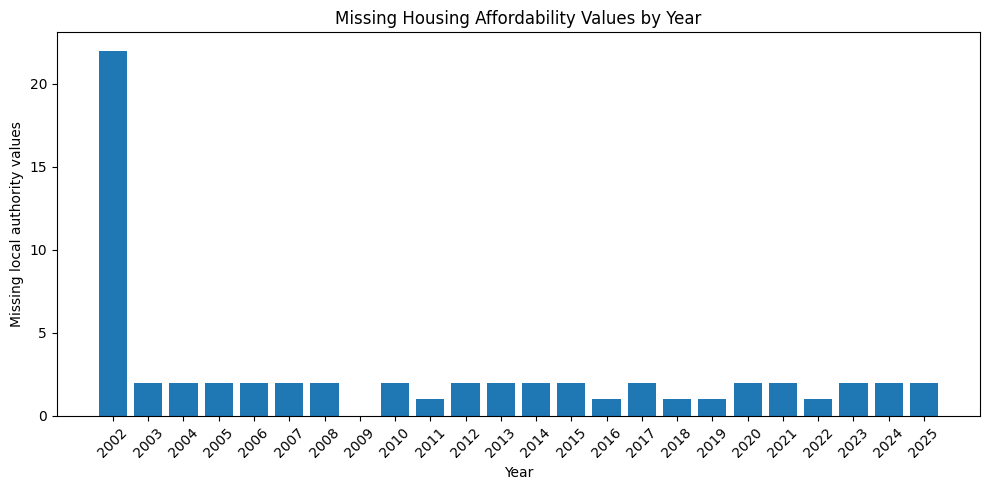

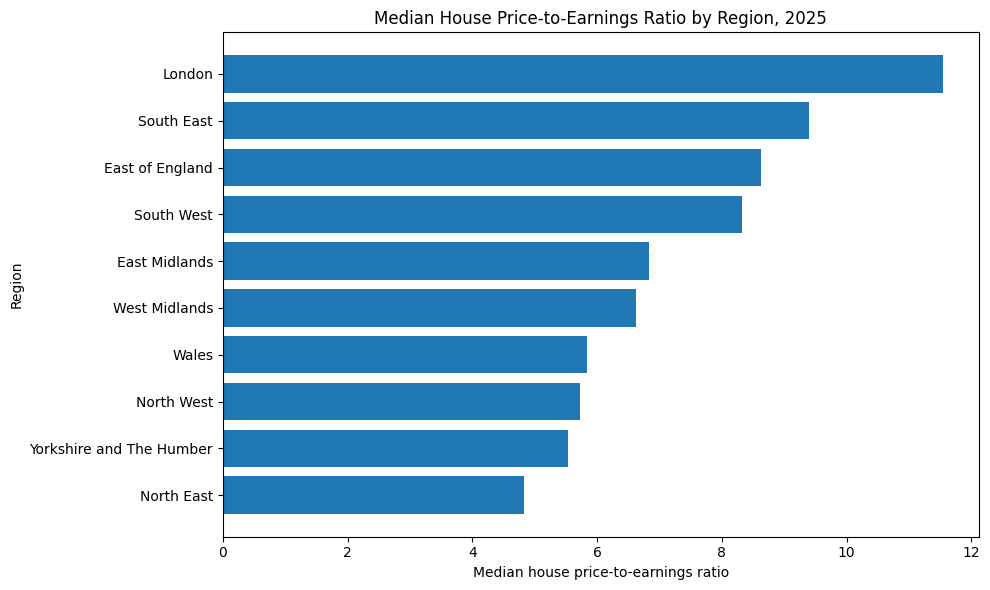

Saved charts:
C:\Users\swapn\official_statistics_quality_audit\outputs\figures\missing_values_by_year.png
C:\Users\swapn\official_statistics_quality_audit\outputs\figures\regional_median_affordability_2025.png


In [40]:
# Create audit charts

figures_folder = base / "outputs" / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

# Chart 1: Missing values by year
missing_by_year = (
    df_long
    .groupby("year")["house_price_to_earnings_ratio"]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="missing_values")
)

plt.figure(figsize=(10, 5))
plt.bar(missing_by_year["year"], missing_by_year["missing_values"])
plt.title("Missing Housing Affordability Values by Year")
plt.xlabel("Year")
plt.ylabel("Missing local authority values")
plt.xticks(missing_by_year["year"], rotation=45)
plt.tight_layout()

missing_chart_path = figures_folder / "missing_values_by_year.png"
plt.savefig(missing_chart_path, dpi=300)
plt.show()

# Chart 2: Regional median affordability ratio in 2025
regional_plot = regional_summary_2025.sort_values("median_ratio", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(regional_plot["country_region_name"], regional_plot["median_ratio"])
plt.title("Median House Price-to-Earnings Ratio by Region, 2025")
plt.xlabel("Median house price-to-earnings ratio")
plt.ylabel("Region")
plt.tight_layout()

regional_chart_path = figures_folder / "regional_median_affordability_2025.png"
plt.savefig(regional_chart_path, dpi=300)
plt.show()

print("Saved charts:")
print(missing_chart_path.resolve())
print(regional_chart_path.resolve())

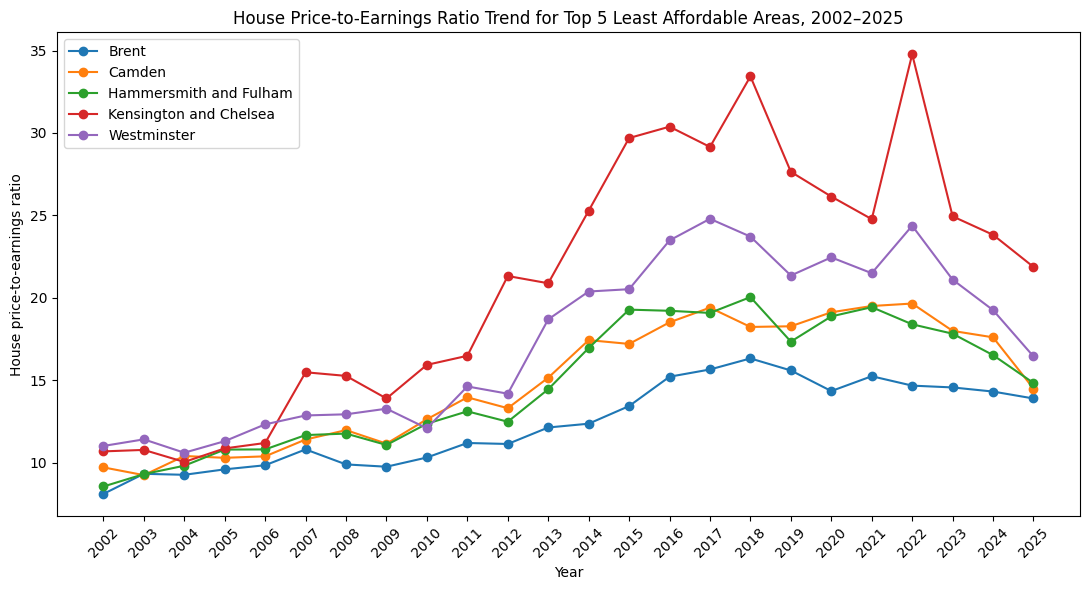

Saved trend chart:
C:\Users\swapn\official_statistics_quality_audit\outputs\figures\top5_unaffordable_trend_2002_2025.png


In [42]:
# Trend chart for top 5 most unaffordable local authorities in 2025

top5_2025_codes = most_unaffordable_2025["local_authority_code"].head(5).tolist()

top5_trend = df_long[
    df_long["local_authority_code"].isin(top5_2025_codes)
].copy()

plt.figure(figsize=(11, 6))

for area_name, group in top5_trend.groupby("local_authority_name"):
    group = group.sort_values("year")
    plt.plot(
        group["year"],
        group["house_price_to_earnings_ratio"],
        marker="o",
        label=area_name
    )

plt.title("House Price-to-Earnings Ratio Trend for Top 5 Least Affordable Areas, 2002–2025")
plt.xlabel("Year")
plt.ylabel("House price-to-earnings ratio")
plt.xticks(sorted(top5_trend["year"].unique()), rotation=45)
plt.legend()
plt.tight_layout()

trend_chart_path = figures_folder / "top5_unaffordable_trend_2002_2025.png"
plt.savefig(trend_chart_path, dpi=300)
plt.show()

print("Saved trend chart:")
print(trend_chart_path.resolve())

In [44]:
# Create quality flags for official-statistics-style audit

quality_flags = df_outlier_audit.copy()

quality_flags["is_missing_value"] = quality_flags["house_price_to_earnings_ratio"].isna()

quality_flags["data_quality_flag"] = "OK"

quality_flags.loc[
    quality_flags["is_missing_value"],
    "data_quality_flag"
] = "Missing ratio value"

quality_flags.loc[
    quality_flags["is_outlier"] & ~quality_flags["is_missing_value"],
    "data_quality_flag"
] = "Statistical outlier"

quality_flags.loc[
    quality_flags["is_missing_value"] & quality_flags["is_outlier"],
    "data_quality_flag"
] = "Missing and outlier"

quality_flag_summary = (
    quality_flags
    .groupby("data_quality_flag")
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

# Save quality-flagged dataset and summary
quality_flags.to_csv(
    base / "data" / "processed" / "housing_affordability_quality_flagged_long.csv",
    index=False
)

quality_flag_summary.to_csv(
    base / "outputs" / "tables" / "quality_flag_summary.csv",
    index=False
)

print("QUALITY FLAG SUMMARY")
print("=" * 50)
display(quality_flag_summary)

print("\nSaved quality-flagged dataset:")
print((base / "data" / "processed" / "housing_affordability_quality_flagged_long.csv").resolve())

print("\nSaved quality flag summary:")
print((base / "outputs" / "tables" / "quality_flag_summary.csv").resolve())

QUALITY FLAG SUMMARY


,data_quality_flag,record_count
1,OK,7461
2,Statistical outlier,110
0,Missing ratio value,61



Saved quality-flagged dataset:
C:\Users\swapn\official_statistics_quality_audit\data\processed\housing_affordability_quality_flagged_long.csv

Saved quality flag summary:
C:\Users\swapn\official_statistics_quality_audit\outputs\tables\quality_flag_summary.csv


In [46]:
# SQL validation and analysis using DuckDB

import duckdb

con = duckdb.connect()

con.register("housing_quality", quality_flags)

sql_record_summary = con.execute("""
    SELECT
        COUNT(*) AS total_records,
        COUNT(DISTINCT local_authority_code) AS local_authorities,
        MIN(year) AS first_year,
        MAX(year) AS latest_year,
        SUM(CASE WHEN is_missing_value THEN 1 ELSE 0 END) AS missing_records,
        SUM(CASE WHEN is_outlier THEN 1 ELSE 0 END) AS outlier_records
    FROM housing_quality;
""").df()

sql_missing_by_year = con.execute("""
    SELECT
        year,
        SUM(CASE WHEN is_missing_value THEN 1 ELSE 0 END) AS missing_values
    FROM housing_quality
    GROUP BY year
    ORDER BY year;
""").df()

sql_top_unaffordable_2025 = con.execute("""
    SELECT
        country_region_name,
        local_authority_code,
        local_authority_name,
        house_price_to_earnings_ratio
    FROM housing_quality
    WHERE year = 2025
      AND house_price_to_earnings_ratio IS NOT NULL
    ORDER BY house_price_to_earnings_ratio DESC
    LIMIT 10;
""").df()

sql_regional_summary_2025 = con.execute("""
    SELECT
        country_region_name,
        COUNT(DISTINCT local_authority_code) AS local_authorities,
        ROUND(AVG(house_price_to_earnings_ratio), 2) AS mean_ratio,
        ROUND(MEDIAN(house_price_to_earnings_ratio), 2) AS median_ratio,
        ROUND(MIN(house_price_to_earnings_ratio), 2) AS min_ratio,
        ROUND(MAX(house_price_to_earnings_ratio), 2) AS max_ratio
    FROM housing_quality
    WHERE year = 2025
      AND house_price_to_earnings_ratio IS NOT NULL
    GROUP BY country_region_name
    ORDER BY median_ratio DESC;
""").df()

# Save SQL outputs
sql_record_summary.to_csv(base / "outputs" / "tables" / "sql_record_summary.csv", index=False)
sql_missing_by_year.to_csv(base / "outputs" / "tables" / "sql_missing_by_year.csv", index=False)
sql_top_unaffordable_2025.to_csv(base / "outputs" / "tables" / "sql_top_unaffordable_2025.csv", index=False)
sql_regional_summary_2025.to_csv(base / "outputs" / "tables" / "sql_regional_summary_2025.csv", index=False)

print("SQL RECORD SUMMARY")
print("=" * 50)
display(sql_record_summary)

print("\nSQL TOP 10 MOST UNAFFORDABLE LOCAL AUTHORITIES, 2025")
print("=" * 50)
display(sql_top_unaffordable_2025)

print("\nSQL REGIONAL SUMMARY, 2025")
print("=" * 50)
display(sql_regional_summary_2025)

SQL RECORD SUMMARY


,total_records,local_authorities,first_year,latest_year,missing_records,outlier_records
0,7632,318,2002,2025,61.0,110.0



SQL TOP 10 MOST UNAFFORDABLE LOCAL AUTHORITIES, 2025


,country_region_name,local_authority_code,local_authority_name,house_price_to_earnings_ratio
0,London,E09000020,Kensington and Chelsea,21.87
1,London,E09000033,Westminster,16.44
2,London,E09000013,Hammersmith and Fulham,14.83
3,London,E09000007,Camden,14.49
4,London,E09000005,Brent,13.89
5,South East,E07000210,Mole Valley,13.51
6,London,E09000009,Ealing,13.21
7,London,E09000014,Haringey,13.02
8,London,E09000027,Richmond upon Thames,12.58
9,South East,E07000207,Elmbridge,12.52



SQL REGIONAL SUMMARY, 2025


,country_region_name,local_authorities,mean_ratio,median_ratio,min_ratio,max_ratio
0,London,32,11.95,11.54,9.59,21.87
1,South East,64,9.43,9.40,6.82,13.51
2,East of England,45,8.73,8.62,6.32,12.39
3,South West,26,8.31,8.32,6.39,11.03
4,East Midlands,35,6.73,6.83,5.36,7.96
5,West Midlands,30,6.95,6.63,4.73,9.17
6,Wales,22,5.79,5.84,3.98,7.46
7,North West,35,5.76,5.73,3.86,8.67
8,Yorkshire and The Humber,15,5.70,5.53,4.46,7.53
9,North East,12,4.92,4.83,4.28,5.89


In [48]:
# Save SQL validation and analysis script for GitHub

sql_script = """
-- Official Statistics Data Quality Audit
-- Housing affordability: house price-to-earnings ratio by local authority
-- Dataset structure: one row per local authority per year

-- 1. Record summary
SELECT
    COUNT(*) AS total_records,
    COUNT(DISTINCT local_authority_code) AS local_authorities,
    MIN(year) AS first_year,
    MAX(year) AS latest_year,
    SUM(CASE WHEN is_missing_value THEN 1 ELSE 0 END) AS missing_records,
    SUM(CASE WHEN is_outlier THEN 1 ELSE 0 END) AS outlier_records
FROM housing_quality;

-- 2. Missing values by year
SELECT
    year,
    SUM(CASE WHEN is_missing_value THEN 1 ELSE 0 END) AS missing_values
FROM housing_quality
GROUP BY year
ORDER BY year;

-- 3. Top 10 least affordable local authorities in 2025
SELECT
    country_region_name,
    local_authority_code,
    local_authority_name,
    house_price_to_earnings_ratio
FROM housing_quality
WHERE year = 2025
  AND house_price_to_earnings_ratio IS NOT NULL
ORDER BY house_price_to_earnings_ratio DESC
LIMIT 10;

-- 4. Regional affordability summary in 2025
SELECT
    country_region_name,
    COUNT(DISTINCT local_authority_code) AS local_authorities,
    ROUND(AVG(house_price_to_earnings_ratio), 2) AS mean_ratio,
    ROUND(MEDIAN(house_price_to_earnings_ratio), 2) AS median_ratio,
    ROUND(MIN(house_price_to_earnings_ratio), 2) AS min_ratio,
    ROUND(MAX(house_price_to_earnings_ratio), 2) AS max_ratio
FROM housing_quality
WHERE year = 2025
  AND house_price_to_earnings_ratio IS NOT NULL
GROUP BY country_region_name
ORDER BY median_ratio DESC;

-- 5. Records requiring review
SELECT
    country_region_name,
    local_authority_code,
    local_authority_name,
    year,
    house_price_to_earnings_ratio,
    data_quality_flag
FROM housing_quality
WHERE data_quality_flag <> 'OK'
ORDER BY year, country_region_name, local_authority_name;
"""

sql_file_path = base / "sql" / "01_housing_affordability_quality_audit.sql"

with open(sql_file_path, "w", encoding="utf-8") as f:
    f.write(sql_script)

print("SQL script saved successfully:")
print(sql_file_path.resolve())

SQL script saved successfully:
C:\Users\swapn\official_statistics_quality_audit\sql\01_housing_affordability_quality_audit.sql


In [50]:
# Create final audit summary table

final_audit_summary = pd.DataFrame([
    {
        "metric": "Total local authorities in source sheet",
        "value": df["local_authority_code"].nunique()
    },
    {
        "metric": "Total year-level records after reshaping",
        "value": df_long.shape[0]
    },
    {
        "metric": "Years covered",
        "value": f"{df_long['year'].min()} to {df_long['year'].max()}"
    },
    {
        "metric": "Missing house price-to-earnings ratio records",
        "value": int(quality_flags["is_missing_value"].sum())
    },
    {
        "metric": "Statistical outlier records flagged",
        "value": int(quality_flags["is_outlier"].sum())
    },
    {
        "metric": "Local authorities with at least one missing year",
        "value": areas_with_missing_detail.shape[0]
    },
    {
        "metric": "Local authorities with valid code pattern",
        "value": int(code_check["valid_local_authority_code_pattern"].sum())
    },
    {
        "metric": "Invalid local authority code patterns",
        "value": invalid_local_authority_codes.shape[0]
    },
    {
        "metric": "Duplicate local authority codes",
        "value": duplicate_local_authority_codes.shape[0]
    },
    {
        "metric": "Areas with both 2002 and 2025 values",
        "value": change_complete.shape[0]
    },
    {
        "metric": "Average affordability ratio in 2002",
        "value": round(change_complete["ratio_2002"].mean(), 2)
    },
    {
        "metric": "Average affordability ratio in 2025",
        "value": round(change_complete["ratio_2025"].mean(), 2)
    },
    {
        "metric": "Average affordability-ratio increase, 2002 to 2025",
        "value": round(change_complete["absolute_change"].mean(), 2)
    }
])

summary_path = base / "outputs" / "tables" / "final_audit_summary.csv"
final_audit_summary.to_csv(summary_path, index=False)

print("Final audit summary saved to:")
print(summary_path.resolve())

final_audit_summary

Final audit summary saved to:
C:\Users\swapn\official_statistics_quality_audit\outputs\tables\final_audit_summary.csv


,metric,value
0,Total local authorities in source sheet,318
1,Total year-level records after reshaping,7632
2,Years covered,2002 to 2025
3,Missing house price-to-earnings ratio records,61
4,Statistical outlier records flagged,110
5,Local authorities with at least one missing year,23
6,Local authorities with valid code pattern,318
7,Invalid local authority code patterns,0
8,Duplicate local authority codes,0
9,Areas with both 2002 and 2025 values,295


In [52]:
# Create a written official-statistics-style audit report

reports_folder = base / "outputs" / "reports"
reports_folder.mkdir(parents=True, exist_ok=True)

top_unaffordable_text = most_unaffordable_2025[
    ["local_authority_name", "country_region_name", "house_price_to_earnings_ratio"]
].head(10).to_string(index=False)

top_affordable_text = most_affordable_2025[
    ["local_authority_name", "country_region_name", "house_price_to_earnings_ratio"]
].head(10).to_string(index=False)

regional_summary_text = regional_summary_2025[
    ["country_region_name", "local_authorities", "mean_ratio", "median_ratio", "min_ratio", "max_ratio"]
].to_string(index=False)

audit_summary_text = final_audit_summary.to_string(index=False)

report_text = f"""
# Official Statistics Data Quality Audit of Local Authority Housing Affordability Indicators

## 1. Project purpose

This project audits an official ONS housing-affordability dataset before analysis. The dataset reports the ratio of median house price to median gross annual residence-based earnings for local authority districts in England and Wales between 2002 and 2025.

The purpose is to demonstrate an official-statistics-style workflow: checking data coverage, local authority code consistency, missing values, outliers, comparability risks and analysis-ready outputs.

## 2. Dataset and structure

Source file: ONS house price to residence-based earnings ratio workbook  
Selected sheet: 5c  
Geography: Local authority districts, England and Wales  
Measure: Ratio of median house price to median gross annual residence-based earnings  
Period: 2002 to 2025

After reshaping the dataset from wide to long format, the audit dataset contains:

{audit_summary_text}

## 3. Main data quality findings

The local-authority code structure was clean. All 318 local authority codes followed the expected English/Welsh area-code pattern, and no duplicate local authority codes were found in the source sheet.

However, the audit found 61 missing year-level ratio values across the long-format dataset. Twenty-three local authorities had at least one missing year. The largest coverage gaps were found for the Isles of Scilly and the City of London, which require caution in longitudinal comparisons.

The audit also flagged 110 statistical outlier records using a year-specific interquartile range rule. These should not automatically be treated as errors. In this dataset, recurring outliers mainly reflect structurally high-affordability-pressure areas, especially inner London boroughs.

## 4. Main analytical findings

Across local authorities with both 2002 and 2025 data, the average house price-to-earnings ratio increased from {round(change_complete["ratio_2002"].mean(), 2)} in 2002 to {round(change_complete["ratio_2025"].mean(), 2)} in 2025. The average absolute increase was {round(change_complete["absolute_change"].mean(), 2)} ratio points.

In 2025, the least affordable local authorities were:

{top_unaffordable_text}

The most affordable local authorities in 2025 were:

{top_affordable_text}

Regional summary for 2025:

{regional_summary_text}

## 5. Quality flags created

Each year-level record was assigned a data quality flag:

- OK
- Missing ratio value
- Statistical outlier

The quality-flagged dataset allows users to analyse the data while preserving information about records that require caution or review.

## 6. Limitations

This audit does not explain the causes of housing affordability differences. It checks data quality and produces descriptive indicators only.

The outlier method is statistical, not substantive. Some outliers may be valid extreme values rather than errors.

Missing values were not imputed. They were preserved and flagged to avoid creating artificial estimates.

Boundary changes and local government reorganisation may affect comparability across time for some areas.

## 7. Employer relevance

This project demonstrates skills relevant to official statistics, public-sector analytics and research analyst roles:

- Python data cleaning
- SQL validation and summarisation
- missing-value auditing
- duplicate and code-pattern checks
- outlier detection
- local-authority public data handling
- reproducible reporting
- clear communication of limitations
- policy-facing statistical interpretation
"""

report_path = reports_folder / "housing_affordability_quality_audit_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Audit report saved successfully:")
print(report_path.resolve())

Audit report saved successfully:
C:\Users\swapn\official_statistics_quality_audit\outputs\reports\housing_affordability_quality_audit_report.md
